# Chinook Digital Music Store — Business Performance Analysis

This notebook presents visualisations for the SQL analysis of the Chinook digital music store database.  
All data was extracted using MySQL Workbench. The full query file is available in [`chinook_analysis.sql`](./chinook_analysis.sql).

**Analysis is organised into four business themes:**
1. Revenue Analysis
2. Customer Analysis
3. Product & Catalog Analysis
4. Sales Team Performance

In [1]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Chart styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

In [2]:
# --- Load Data ---
df_monthly       = pd.read_csv('results/monthly_revenue.csv')
df_cumulative    = pd.read_csv('results/cumulative_revenue.csv')
df_mom           = pd.read_csv('results/mom_change.csv')
df_artists       = pd.read_csv('results/top_artists.csv')
df_genres        = pd.read_csv('results/genre_share.csv')
df_segmentation  = pd.read_csv('results/customer_segmentation.csv')
df_efficiency    = pd.read_csv('results/artist_efficiency.csv')

---
## 1. Revenue Analysis

### 1.1 Monthly Revenue Trend

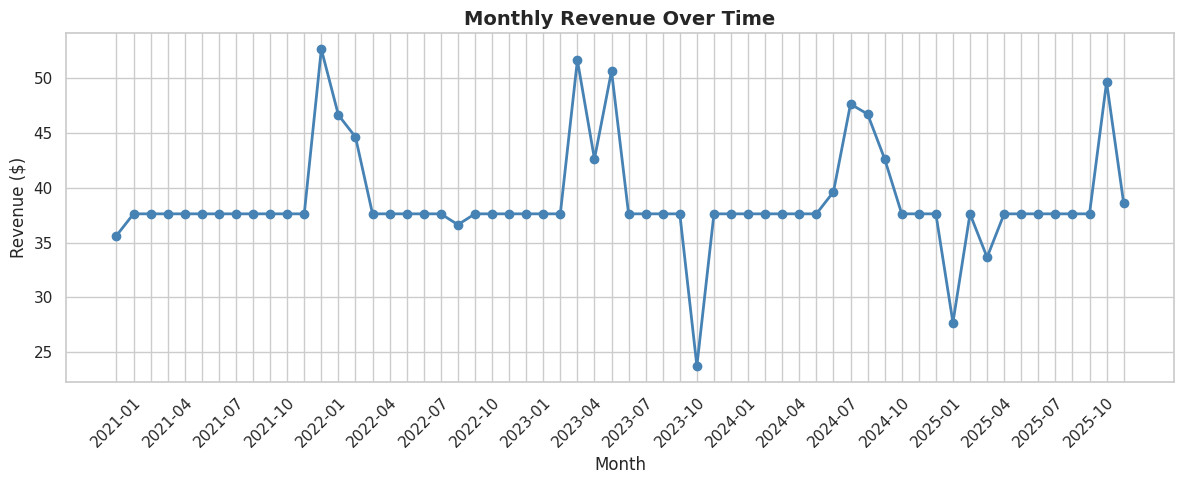

In [3]:
fig, ax = plt.subplots()

ax.plot(df_monthly['date_month'], df_monthly['revenue'], marker='o', linewidth=2, color='steelblue')

ax.set_title('Monthly Revenue Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.tick_params(axis='x', rotation=45)
# Show every 3rd label to avoid overcrowding
every_nth = 3
for n, label in enumerate(ax.xaxis.get_ticklabels()):
    if n % every_nth != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** Revenue shows consistent month-to-month activity with no clear long-term growth trend, consistent with a stable but small customer base. The 2021 period shows unusually uniform values, likely reflecting the store's launch period with incomplete data.

### 1.2 Cumulative Revenue Over Time

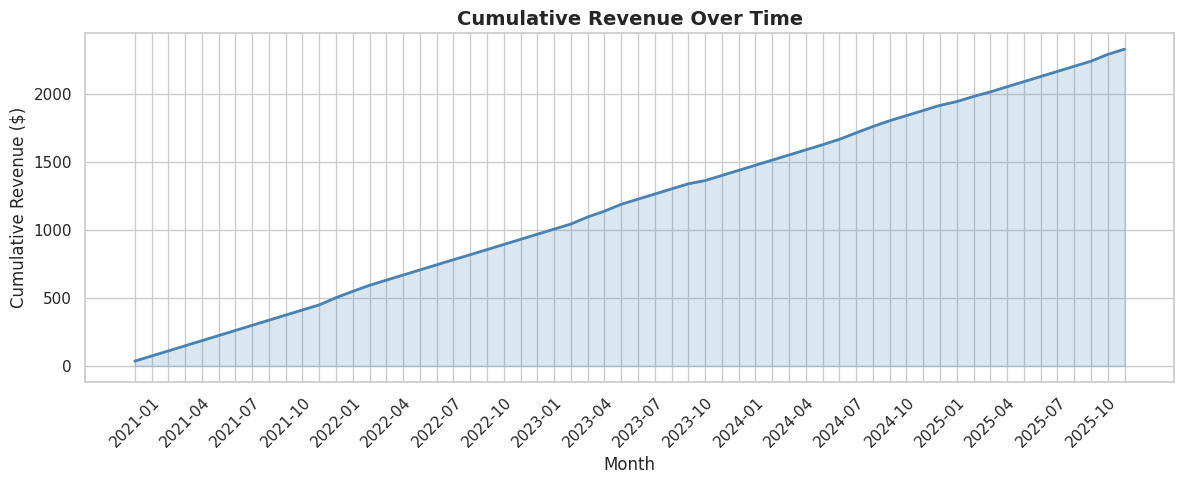

In [4]:
fig, ax = plt.subplots()

ax.fill_between(df_cumulative['date_month'], df_cumulative['cumulative_revenue'], alpha=0.2, color='steelblue')
ax.plot(df_cumulative['date_month'], df_cumulative['cumulative_revenue'], linewidth=2, color='steelblue')

ax.set_title('Cumulative Revenue Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Revenue ($)')
ax.tick_params(axis='x', rotation=45)
every_nth = 3
for n, label in enumerate(ax.xaxis.get_ticklabels()):
    if n % every_nth != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** Cumulative revenue grows steadily and linearly over the period, suggesting consistent sales volume without significant acceleration or decline.

### 1.3 Month-over-Month Revenue Change (%)

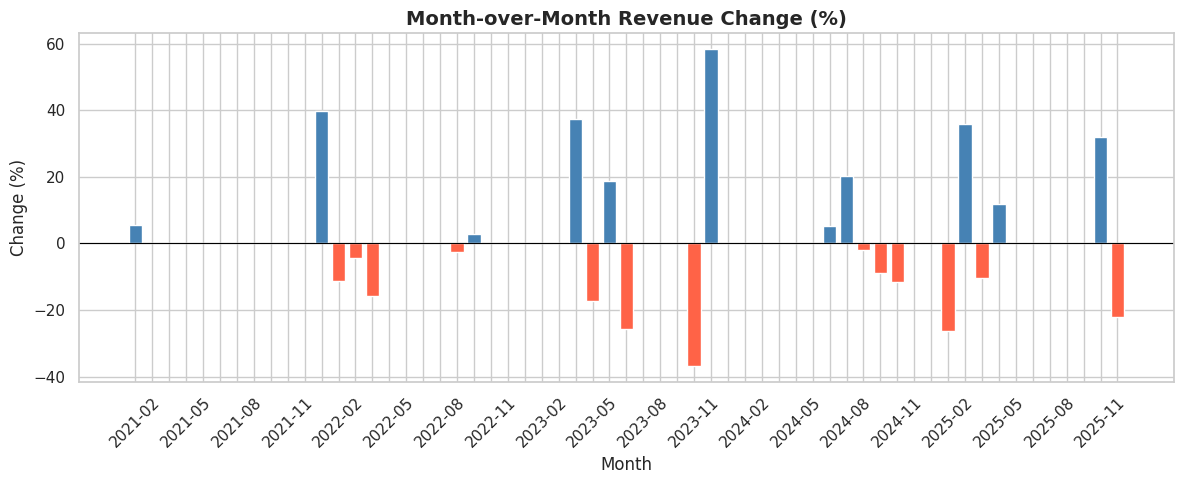

In [5]:
# Drop the first row (no previous month to compare to)
df_mom_plot = df_mom.dropna(subset=['pct_change'])

colors = ['tomato' if x < 0 else 'steelblue' for x in df_mom_plot['pct_change']]

fig, ax = plt.subplots()

ax.bar(df_mom_plot['date_month'], df_mom_plot['pct_change'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)

ax.set_title('Month-over-Month Revenue Change (%)')
ax.set_xlabel('Month')
ax.set_ylabel('Change (%)')
ax.tick_params(axis='x', rotation=45)
every_nth = 3
for n, label in enumerate(ax.xaxis.get_ticklabels()):
    if n % every_nth != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** Revenue shows high month-to-month volatility with swings between sharp gains and losses. This is consistent with a small customer base where individual large orders can significantly shift monthly totals.

---
## 2. Customer Analysis

### 2.1 Customer Segmentation by Spending

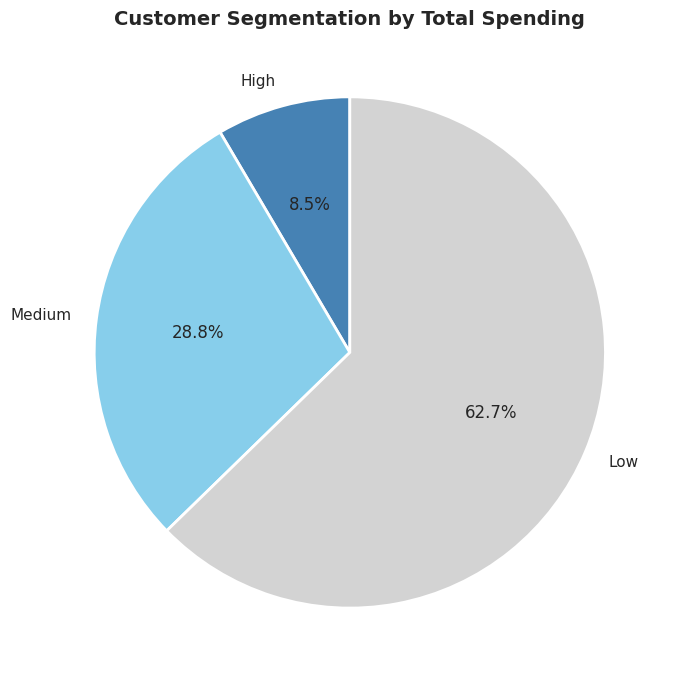

In [6]:
segment_counts = df_segmentation['segment'].value_counts().reindex(['High', 'Medium', 'Low'])

fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=['steelblue', 'skyblue', 'lightgrey'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax.set_title('Customer Segmentation by Total Spending')

plt.tight_layout()
plt.show()

**Insight:** Spending is tightly clustered between \$36.64 and \$49.62, with low variance (std dev = \$2.89). Thresholds were set empirically rather than statistically, as one standard deviation below the mean fell outside the actual data range, a limitation of the dataset's uniformity.

---
## 3. Product & Catalog Analysis

### 3.1 Top 10 Best-Selling Artists by Revenue

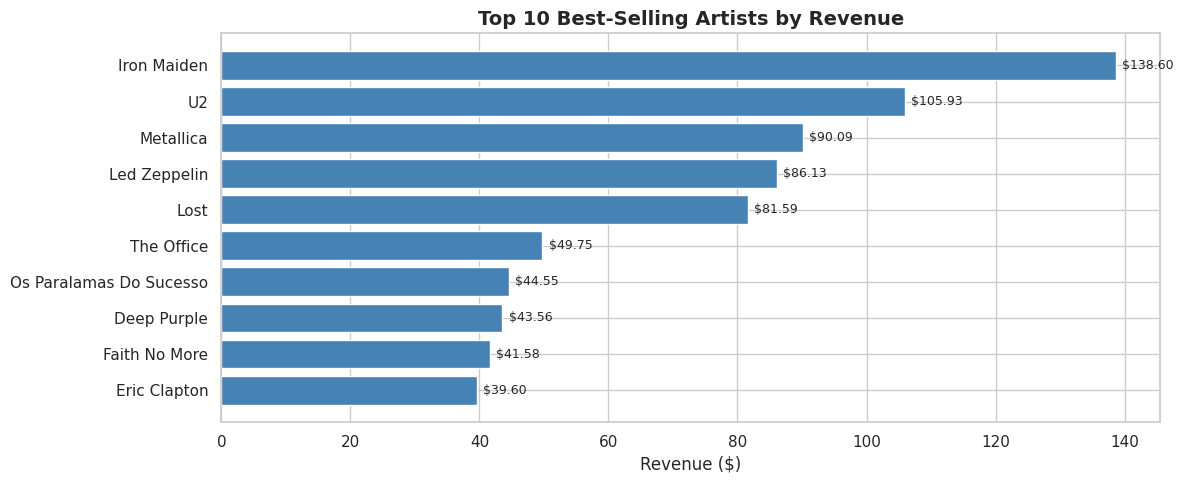

In [7]:
df_artists_sorted = df_artists.sort_values('revenue', ascending=True)

fig, ax = plt.subplots()

ax.barh(df_artists_sorted['artist'], df_artists_sorted['revenue'], color='steelblue')

ax.set_title('Top 10 Best-Selling Artists by Revenue')
ax.set_xlabel('Revenue ($)')
ax.set_ylabel('')

# Add value labels at end of each bar
for i, (value, name) in enumerate(zip(df_artists_sorted['revenue'], df_artists_sorted['artist'])):
    ax.text(value + 1, i, f'${value:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight:** Iron Maiden leads with $138.60, nearly 32% more than second-placed U2. Notably, 'Lost' and 'The Office' appear in the top 10. These are TV shows sold as video content, highlighting that the Chinook catalog includes non-music media.

### 3.2 Genre Revenue Share

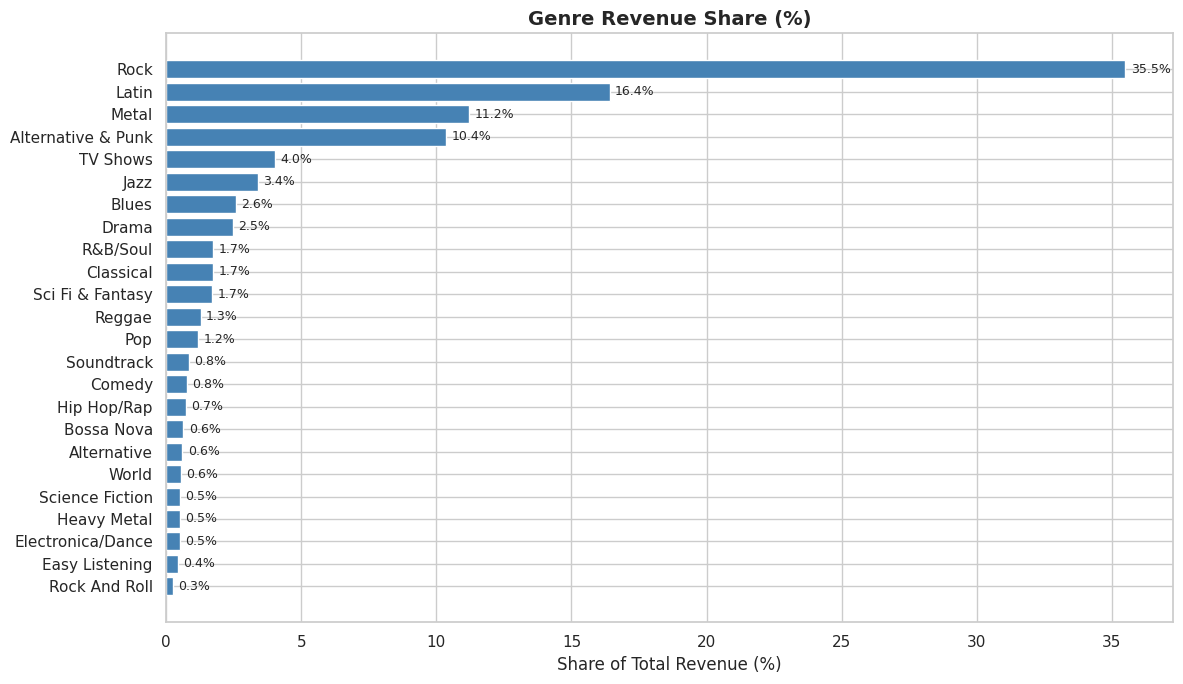

In [8]:
df_genres_sorted = df_genres.sort_values('revenue', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(df_genres_sorted['genre'], df_genres_sorted['percentage'], color='steelblue')

ax.set_title('Genre Revenue Share (%)')
ax.set_xlabel('Share of Total Revenue (%)')
ax.set_ylabel('')

# Add percentage labels
for bar, value in zip(bars, df_genres_sorted['percentage']):
    ax.text(value + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{value:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight:** Rock dominates revenue share by a significant margin, consistent with the catalog's composition. genres at the bottom of the ranking represent niche audiences that may be underserved or simply reflect lower catalog depth.

### 3.3 Artist Catalog Efficiency — Revenue per Track vs Total Revenue

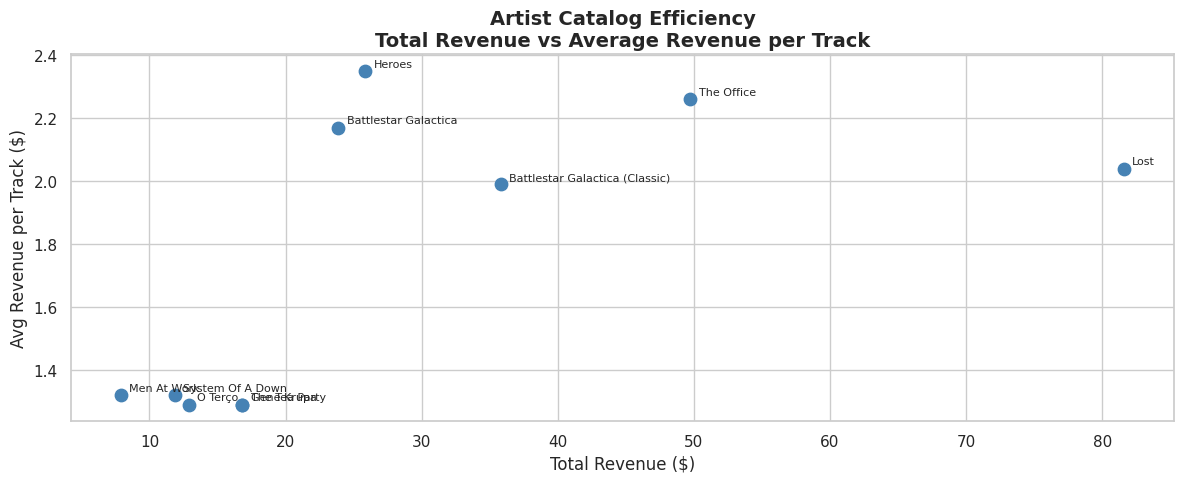

In [9]:
fig, ax = plt.subplots()

ax.scatter(df_efficiency['total_revenue'], df_efficiency['avg_revenue_per_track'],
           color='steelblue', s=80, zorder=3)

# Label each point with artist name
for _, row in df_efficiency.iterrows():
    ax.annotate(row['artist_name'],
                (row['total_revenue'], row['avg_revenue_per_track']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_title('Artist Catalog Efficiency\nTotal Revenue vs Average Revenue per Track')
ax.set_xlabel('Total Revenue ($)')
ax.set_ylabel('Avg Revenue per Track ($)')

plt.tight_layout()
plt.show()

**Insight:**  TV shows consistently outperform music tracks both in total revenue as well as average per track (episode).

---
*Analysis performed on the [Chinook Database](https://github.com/lerocha/chinook-database) using MySQL Workbench and Python.*